# Homework 3: Monte Carlo Radiative Transfer with Scattering and Clouds
## Part I: Isotropic Scattering
### 1.1 Model Construction

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_columns', None)

In [36]:
# CONSTANTS
g0 = 9.8 # m/s2
R = 287 # J/kg/K
H = 8000 # scale height 8km

def calc_tau(zeta):
    return - 1 * np.log(1 - zeta)

def scale_height(t_avg):
    return t_avg * R / g0

In [37]:
def coord_rotation(theta0, phi0, theta_sca, phi_sca):
    k0 = np.array(
        [
            np.cos(phi0)*np.sin(theta0),
            np.sin(phi0)*np.sin(theta0),
            -np.cos(theta0)
        ]
    )

    zp = k0
    if (k0[0] == 0) and (k0[1] == 0):
        xp = np.array([1,0,0])
    else:
        xp = np.array(
            [
                -k0[1],
                k0[0],
                0
            ]
        ) / np.sqrt(k0[0]**2+k0[1]**2)
    
    yp = np.cross(zp,xp)

    # Bug fix 1: cos(phi_sca) must multiply sin(theta_sca), not be inside sin()
    kp = np.array([
        np.sin(theta_sca)*np.cos(phi_sca),
        np.sin(theta_sca)*np.sin(phi_sca),
        np.cos(theta_sca)
    ])

    # Bug fix 2: stack basis vectors as columns so A @ kp rotates local -> global
    A = np.column_stack([xp, yp, zp])

    knew = np.matmul(A,kp)

    knew_norm = knew / np.linalg.norm(knew)

    theta_new = np.arccos(-knew_norm[2])
    # Bug fix 3: arctan2 handles all quadrants; arctan is restricted to (-pi/2, pi/2)
    # which always gives cos(phi) > 0, biasing every step toward +x
    phi_new = np.arctan2(knew_norm[1], knew_norm[0])

    return theta_new, phi_new

# theta_new, phi_new = coord_rotation(theta0 = np.deg2rad(50), phi0 = np.deg2rad(37), theta_sca=np.deg2rad(30),phi_sca=np.deg2rad(135))

def photon_scattering_iso(theta0, phi0):

    cdf = np.random.uniform()
    cos_theta = 2*cdf - 1
    theta_sca = np.arccos(cos_theta)
    phi_sca = np.random.uniform(0,2*np.pi)

    theta_new, phi_new = coord_rotation(theta0, phi0, theta_sca, phi_sca)
    return theta_new, phi_new

In [38]:
def coord_rotation_vec(theta0, phi0, theta_sca, phi_sca):
    """Vectorized coordinate rotation for N photons simultaneously.
    All inputs are 1-D arrays of length N; returns (theta_new, phi_new)."""
    k0 = np.column_stack([
        np.cos(phi0) * np.sin(theta0),
        np.sin(phi0) * np.sin(theta0),
        -np.cos(theta0),
    ])                                              # (N, 3) current direction

    zp      = k0
    norm_xy = np.hypot(k0[:, 0], k0[:, 1])
    vert    = norm_xy < 1e-10                       # photons traveling straight up/down
    safe    = np.where(vert, 1.0, norm_xy)

    xp = np.column_stack([
        np.where(vert,  1.0, -k0[:, 1] / safe),
        np.where(vert,  0.0,  k0[:, 0] / safe),
        np.zeros(len(theta0)),
    ])                                              # (N, 3)
    yp = np.cross(zp, xp)                          # (N, 3)

    kp = np.column_stack([
        np.sin(theta_sca) * np.cos(phi_sca),
        np.sin(theta_sca) * np.sin(phi_sca),
        np.cos(theta_sca),
    ])                                              # (N, 3) scattered direction in local frame

    A    = np.stack([xp, yp, zp], axis=2)          # (N, 3, 3) rotation matrix
    knew = np.einsum('nij,nj->ni', A, kp)          # (N, 3)
    knew /= np.linalg.norm(knew, axis=1, keepdims=True)

    return (
        np.arccos(np.clip(-knew[:, 2], -1.0, 1.0)),
        np.arctan2(knew[:, 1], knew[:, 0]),
    )


def photon_scattering_iso_vec(theta0, phi0):
    """Vectorized isotropic scattering for N photons simultaneously."""
    N       = len(theta0)
    cos_th  = 2.0 * np.random.uniform(size=N) - 1.0
    theta_s = np.arccos(cos_th)
    phi_s   = np.random.uniform(0.0, 2.0 * np.pi, size=N)
    return coord_rotation_vec(theta0, phi0, theta_s, phi_s)

In [39]:
def photon_path(theta, w, tau_star, keep_path = False):

    zeta = np.random.uniform()
    
    x_path = [0]
    y_path = [0]
    z_path = [H] # TOA
    phi = 0

    mu = np.abs(np.cos(theta).round(15)) # correct for python precision error
    tau = calc_tau(zeta=zeta)
    tau_star_path = tau_star / mu
    L_photon = (H / mu) * (tau / tau_star_path)

    x_new = x_path[0] + L_photon * np.sin(theta) * np.cos(phi)
    y_new = y_path[0] + L_photon * np.sin(theta) * np.sin(phi)
    z_new = z_path[0] - L_photon * np.cos(theta)

    x_path.append(x_new)
    y_path.append(y_new)
    z_path.append(z_new)

    ext_events = 0
    while ext_events < 500:

        if z_new < 0:
            break
        elif z_new > H:
            break
        elif zeta < w:
            # scattering 
            theta, phi = photon_scattering_iso(theta0 = theta, phi0 = phi)

            mu = np.abs(np.cos(theta).round(15)) # correct for python precision error
            # Bug fix 4: draw a new random zeta for each scatter hop so the
            # free-path length is independently re-sampled at every event
            zeta = np.random.uniform()
            tau = calc_tau(zeta=zeta)
            tau_star_path = tau_star / mu
            L_photon = (H / mu) * (tau / tau_star_path)

            x_new = x_new + L_photon * np.sin(theta) * np.cos(phi)
            y_new = y_new + L_photon * np.sin(theta) * np.sin(phi)
            z_new = z_new - L_photon * np.cos(theta)

            if keep_path:
                x_path.append(x_new)
                y_path.append(y_new)
                z_path.append(z_new)

            ext_events += 1

        else:
            break

    if keep_path:
        return np.array(x_path), np.array(y_path), np.array(z_path), ext_events
    else:
        return x_new, y_new, z_new, ext_events

In [40]:
# direct    == first hop hits surface  (n_scatter == 0, z < 0)
# diffuse   == scattered at least once, then exits at surface (n_scatter > 0, z < 0)
# albedo    == exits at TOA           (z > H)
# absorbed  == none of the above

def monte_carlo_model(theta, w, tau_star, num_photons=10e4, ext_event_count=False):
    N         = int(num_photons)
    theta_rad = np.deg2rad(theta)

    # Per-photon state
    z         = np.full(N, float(H))
    theta_arr = np.full(N, theta_rad)
    phi_arr   = np.zeros(N)
    active    = np.ones(N,  dtype=bool)
    n_scatter = np.zeros(N, dtype=int)

    # Outcome masks
    direct_mask  = np.zeros(N, dtype=bool)
    diffuse_mask = np.zeros(N, dtype=bool)
    albedo_mask  = np.zeros(N, dtype=bool)

    while active.any():
        idx  = np.where(active)[0]

        # Draw random zeta; it determines both path length and scatter/absorb fate
        zeta  = np.random.uniform(size=len(idx))
        tau   = -np.log(1.0 - zeta)
        # Path length simplification: L = (H/mu)*(tau/tau_star_path) where
        # tau_star_path = tau_star/mu  →  mu cancels  →  L = H*tau/tau_star
        L     = H * tau / tau_star
        z_new = z[idx] - L * np.cos(theta_arr[idx])

        hit_sfc = z_new < 0
        hit_toa = z_new > H
        scatter = ~hit_sfc & ~hit_toa & (zeta < w)   # still in atmosphere and scatters

        z[idx] = z_new

        # Classify exits
        first_hop = n_scatter[idx] == 0
        direct_mask [idx[hit_sfc &  first_hop]] = True
        diffuse_mask[idx[hit_sfc & ~first_hop]] = True
        albedo_mask [idx[hit_toa]]              = True

        # Deactivate photons that exited or were absorbed (~scatter covers all three)
        active[idx[~scatter]] = False

        # Update direction for photons that scatter
        scat_idx = idx[scatter]
        if len(scat_idx):
            theta_arr[scat_idx], phi_arr[scat_idx] = photon_scattering_iso_vec(
                theta_arr[scat_idx], phi_arr[scat_idx]
            )
            n_scatter[scat_idx] += 1

    results = [int(direct_mask.sum()), int(diffuse_mask.sum()), int(albedo_mask.sum())]

    if ext_event_count:
        ext = n_scatter + 1          # total extinction events = scatter hops + initial hop
        results += [
            float(ext[direct_mask ].mean()) if direct_mask .any() else np.nan,
            float(ext[diffuse_mask].mean()) if diffuse_mask.any() else np.nan,
            float(ext[albedo_mask ].mean()) if albedo_mask .any() else np.nan,
        ]

    return results

### 1.2 Model Verification
- Test case 1: single scatter albedo $\tilde{\omega}$ ranges from 0 to 1. Plot fraction absorbed when optical depth is very high (10). Plot should show 0% absorbed when $\tilde{\omega}=1$ and 100% absorbed when $\tilde{\omega}=0$.
    - Note: first particle interaction should be on the $-1$:$1$ line, but the plot shows the final extinction of the particle, biasing towards absorption.
- Test case 2: Direct transmittance is independent of $\tilde{\omega}$. Direct transmittance depends on $\tau^*$ and should be 100% for small optical depths and zero for large optical depths.

In [41]:
num_photons = 10e4
w = np.linspace(0,1,50)

Text(0.5, 1.0, 'Test case 1: absorption vs w')

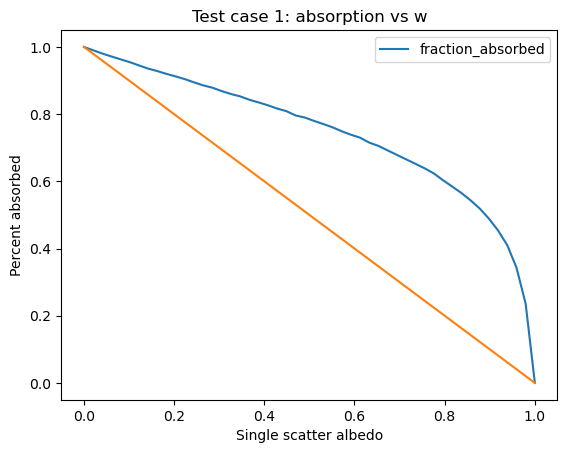

In [42]:
df_test_1 = pd.DataFrame({
    'w':w
})

df_test_1['fraction_absorbed'] = df_test_1.apply(lambda x: 1 - np.array(monte_carlo_model(theta = 0, w = x['w'], tau_star = 10, num_photons=num_photons)).sum()/num_photons,axis=1)

df_test_1.set_index('w').plot()
plt.plot(np.linspace(0,1,50),np.linspace(1,0,50))

plt.xlabel('Single scatter albedo')
plt.ylabel('Percent absorbed')
plt.title('Test case 1: absorption vs w')

Text(0.5, 1.0, 'Test case 2: tau dependence of direct transmittance')

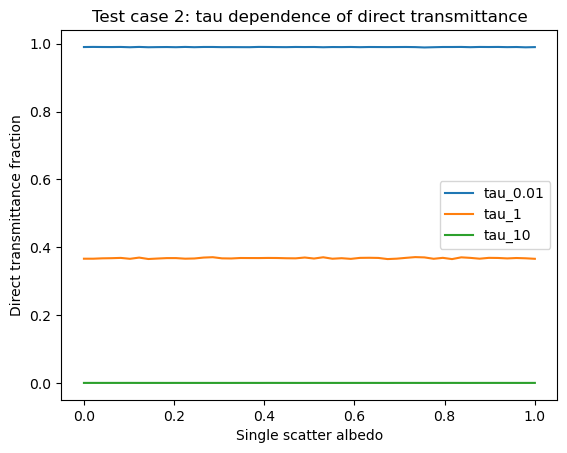

In [43]:
df_test_2 = pd.DataFrame({
    'w':w
})

df_test_2['tau_0.01'] = df_test_2.apply(lambda x: monte_carlo_model(theta = 0, w = x['w'], tau_star = 0.01, num_photons=num_photons)[0]/num_photons,axis=1)
df_test_2['tau_1'] = df_test_2.apply(lambda x: monte_carlo_model(theta = 0, w = x['w'], tau_star = 1, num_photons=num_photons)[0]/num_photons,axis=1)
df_test_2['tau_10'] = df_test_2.apply(lambda x: monte_carlo_model(theta = 0, w = x['w'], tau_star = 10, num_photons=num_photons)[0]/num_photons,axis=1)

df_test_2.set_index('w').plot()
# plt.plot(np.linspace(0,1,50),np.linspace(1,0,50))

plt.xlabel('Single scatter albedo')
plt.ylabel('Direct transmittance fraction')
plt.title('Test case 2: tau dependence of direct transmittance')

### 1.3 Questions

- For $\tilde{\omega}$ increasing from 0 → 1, how does the surface direct and diffuse transmittance, and the albedo, change?

The direct surface transmittance is not a function of single scatter albedo, as demonstrated in test case 2. I set the optical depth to 1, so the direct surface transmittance is a factor of $e^{-1}$ less than the initial photon concentration. The albedo and diffuse transmittance increase with $\tilde{\omega}$, but not necessarily linearly since a photon can go through multiple scattering events before extinction (absorbed, hitting surface, or scattered back to space). This means absorption is favored for lower $\tilde{\omega}$ values. Albedo is higher than diffuse transmittance because photons enter through the top of the atmosphere so they are more likely to be scattered back out than scattered down to the surface when scattering is isotropic.

Text(0.5, 1.0, 'Variation in extinction events')

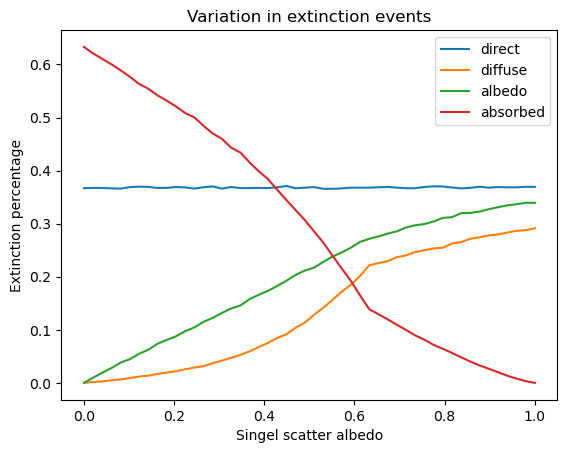

In [44]:
df = pd.DataFrame({
    'w':w
})

df_scattering = df.apply(lambda x: monte_carlo_model(theta = 0, w = x['w'], tau_star = 1, num_photons=num_photons),axis=1,result_type='expand').rename(columns={0:'direct',1:'diffuse',2:'albedo'})

df = pd.concat([df,df_scattering],axis=1).set_index('w')
df['absorbed'] = num_photons - df.sum(axis=1)

(df / num_photons).plot()
plt.ylabel('Extinction percentage')
plt.xlabel('Singel scatter albedo')
plt.title('Variation in extinction events')

- For $\tau \ll 1$, what is the relationship between diffuse radiation at the surface and $\tilde{\omega}$, $\tau$, and $\mu_0$, and how does this compare to an approximate analytical solution to the RTE?

An approximate analytical solution to the RTE is: Tdiffuse = ($\tau$ / $\mu_0$) * $\tilde{\omega}$ * 0.5

This is derived from a taylor series approximation of 1 - direct transmittance, which gives the extinct photons. The fraction scattered vs absorbed is the single scatter albedo, and then since scattering is isotropic, half go in the downward direction to the surface.

Based on the first set of plots, to first order surface transmittance is a function of optical depth. Incidence angle is fairly constant until $> 80°$ when surface transmittance drops off significantly.

<!-- Combining into one plot, we can see that the analytical approximation does not work for high values of $\mu_0$. But for lower values of $\mu_0$ and $\tilde{\omega}$, the analytical approximation does very well. When $\tilde{\omega}$ is zero, the analytical approximation is an overestimate because there is no diffuse transmittance — photons are either directly transmitted or absorbed. And when both $\tilde{\omega}$ and $\mu_0$ are higher values, the analytical approximation is an overestimate because more photons will be scattered out the top of the atmosphere. -->

The analytical approximation captures the first order dependence on tau. This is aparent for the low incidence angles. The analytical solution works best for higher single scatter albedos. For the case of theta = 85, the approximation falls off for higher values of tau. This tracks with importance of incidence angle when theta > 80. The analytical approximation also puts too much emphasis on the single scatter albedo, having a linear dependence on it. We can see from the first set of figures that aside from w = 0, diffuse transmittance is independent of single scatter albedo.


In [45]:
df_w = pd.DataFrame({
    'w':w
})

df_w_scattering = df_w.apply(lambda x: monte_carlo_model(theta = 0, w = x['w'], tau_star = 0.01, num_photons=num_photons),axis=1,result_type='expand').rename(columns={0:'direct',1:'diffuse',2:'albedo'})

df_w = pd.concat([df_w,df_w_scattering],axis=1).set_index('w')
df_w['absorbed'] = num_photons - df_w.sum(axis=1)
df_w['surface'] = df_w['direct'] + df_w['diffuse']

df_t = pd.DataFrame({
    't':np.linspace(0.0001,0.1,100)
})

df_t_scattering = df_t.apply(lambda x: monte_carlo_model(theta = 0, w = 0.5, tau_star = x['t'], num_photons=num_photons),axis=1,result_type='expand').rename(columns={0:'direct',1:'diffuse',2:'albedo'})

df_t = pd.concat([df_t,df_t_scattering],axis=1).set_index('t')
df_t['absorbed'] = num_photons - df_t.sum(axis=1)
df_t['surface'] = df_t['direct'] + df_t['diffuse']

df_u = pd.DataFrame({
    'u':np.linspace(0,89,100)
})

df_u_scattering = df_u.apply(lambda x: monte_carlo_model(theta = x['u'], w = 0.5, tau_star = 0.01, num_photons=num_photons),axis=1,result_type='expand').rename(columns={0:'direct',1:'diffuse',2:'albedo'})

df_u = pd.concat([df_u,df_u_scattering],axis=1).set_index('u')
df_u['absorbed'] = num_photons - df_u.sum(axis=1)
df_u['surface'] = df_u['direct'] + df_u['diffuse']

Text(0.5, 1.0, 'w = 0.5, tau = 0.01')

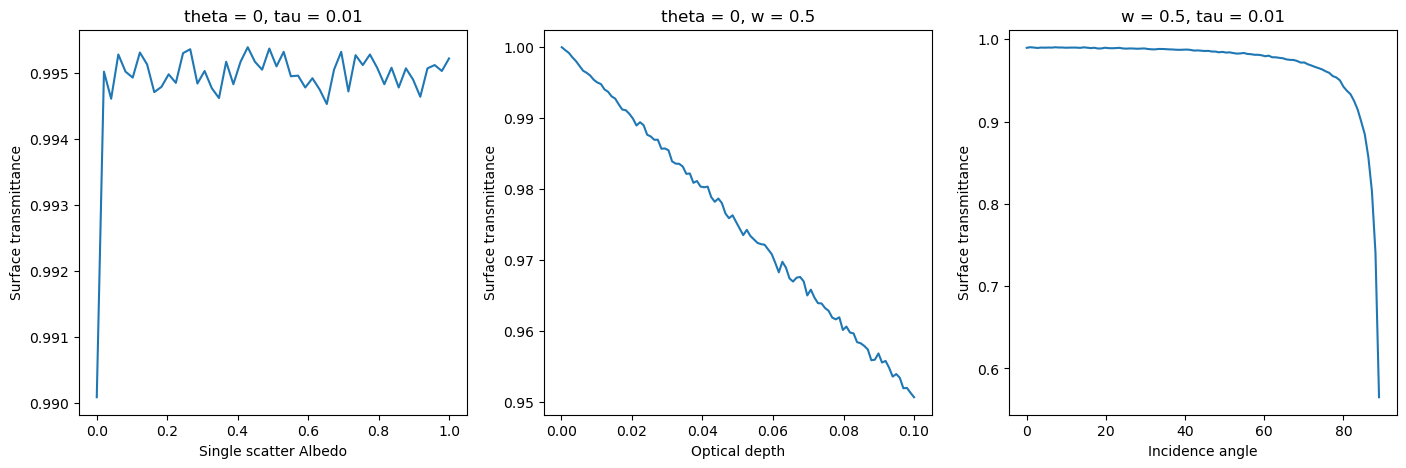

In [46]:
fig, ax = plt.subplots(1,3,figsize=(17,5))

(df_w['surface']/num_photons).plot(ax=ax[0])
ax[0].set_xlabel('Single scatter Albedo')
ax[0].set_ylabel('Surface transmittance')
ax[0].set_title("theta = 0, tau = 0.01")

(df_t['surface']/num_photons).plot(ax=ax[1])
ax[1].set_xlabel('Optical depth')
ax[1].set_ylabel('Surface transmittance')
ax[1].set_title("theta = 0, w = 0.5")

(df_u['direct']/num_photons).plot(ax=ax[2])
ax[2].set_xlabel('Incidence angle')
ax[2].set_ylabel('Surface transmittance')
ax[2].set_title("w = 0.5, tau = 0.01")

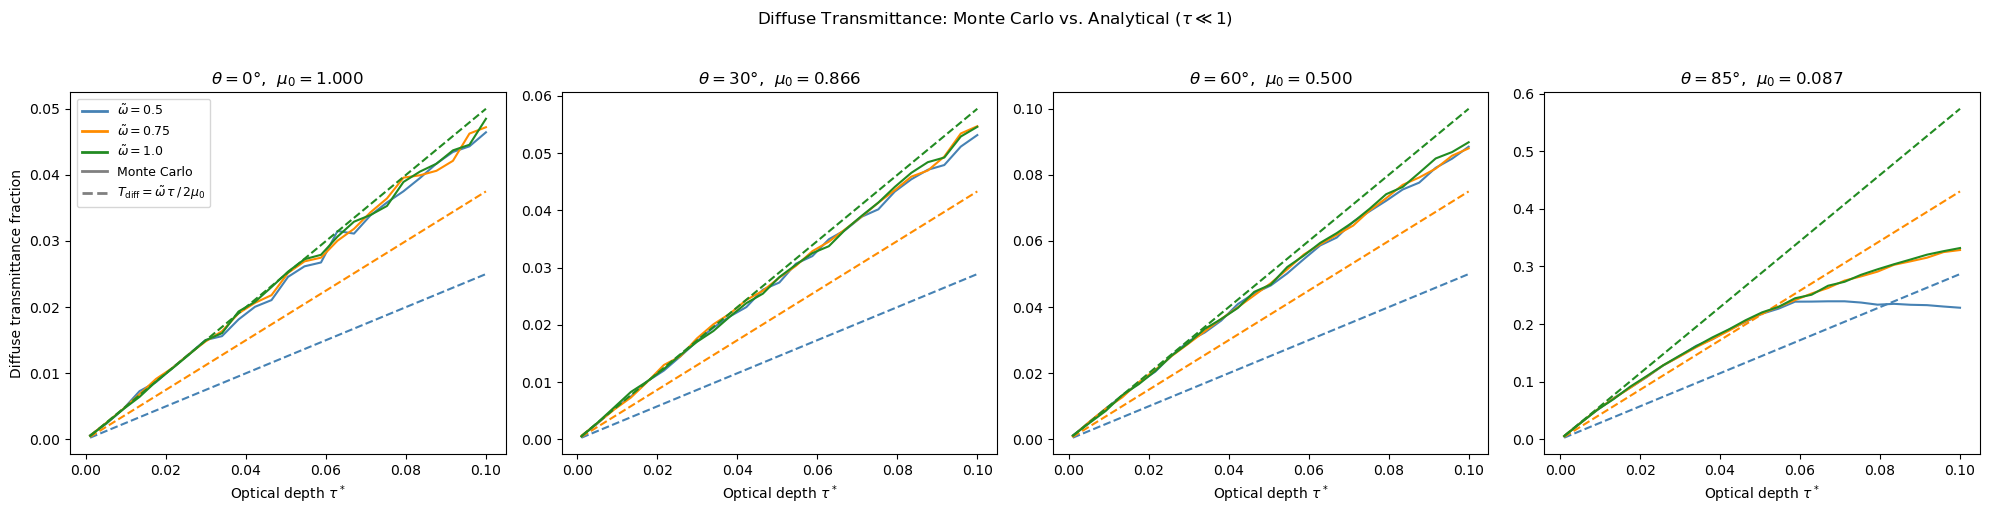

In [67]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

thetas  = [0, 30, 60, 85]
omegas  = [0.5, 0.75, 1.0]
tau_arr = np.linspace(0.001, 0.1, 25)
colors  = ['steelblue', 'darkorange', 'forestgreen']

for ax, theta in zip(axes, thetas):
    mu = np.cos(np.deg2rad(theta))

    for omega, color in zip(omegas, colors):
        # Monte Carlo: extract diffuse count at each tau
        mc_diff = np.array([
            monte_carlo_model(theta=theta, w=omega, tau_star=tau, num_photons=num_photons)[1]
            for tau in tau_arr
        ]) / num_photons

        ax.plot(tau_arr, mc_diff, color=color, linewidth=1.5)

        # Analytical: T_diff = (tau / mu) * omega * 0.5  (undefined when mu = 0)
        if mu > 1e-6:
            ax.plot(tau_arr, (tau_arr / mu) * omega * 0.5,
                    color=color, linestyle='--', linewidth=1.5)

    mu_str = f'{mu:.3f}' if mu > 1e-6 else '0'
    ax.set_title(fr'$\theta = {theta}°$,  $\mu_0 = {mu_str}$')
    ax.set_xlabel(r'Optical depth $\tau^*$')

axes[0].set_ylabel('Diffuse transmittance fraction')

# Split legend: colors = omega, line style = source
color_handles = [
    Line2D([0], [0], color=c, linewidth=2, label=fr'$\tilde{{\omega}} = {o}$')
    for c, o in zip(colors, omegas)
]
style_handles = [
    Line2D([0], [0], color='grey', linewidth=2, linestyle='-',  label='Monte Carlo'),
    Line2D([0], [0], color='grey', linewidth=2, linestyle='--', label=r'$T_\mathrm{diff} = \tilde{\omega}\,\tau\,/\,2\mu_0$'),
]
axes[0].legend(handles=color_handles + style_handles, loc='upper left', fontsize=9)

plt.suptitle(r'Diffuse Transmittance: Monte Carlo vs. Analytical ($\tau \ll 1$)', y=1.02)
plt.tight_layout()
plt.show()

- Prove that the sky is blue and sunsets are red.

In the Rayleigh regime, where the size of the scattering particle is much smaller than the wavelength, extinction efficiency is proportional to $\lambda^{-4}$. Since blue light has a smaller wavelength than red light, it has a larger extinction efficiency. Since the atmosphere does not absorb visible light, this extinction is primarily from scattering. For this reason, the sky appears blue, since the blue light arriving from the sun is being scattered more efficiently. Red light (and visible wavelengths longer than blue) is not scattered as well, so this light arrives at the surface via direct transmittance. On the other hand, at sunset, since the atmosphere is scattering blue light so efficiently, it is mostly being scattered back out to space due to the large incidence angle. So in this case, it is primarily red light reaching the surface and making the sky near the sun appear red.

I can prove this using my model by deriving a wavelength dependence for optical depth.

$$Q_{\text{ext},\lambda} = Q_{\text{ext,atm}} \cdot \lambda^{-4}$$

$$\beta_{\text{ext}} = Q_{\text{ext}} \cdot N \pi r^2$$

$$\tau^* = \int_0^{\text{TOA}} \beta_{\text{ext}} \, dz = \int_0^{\text{TOA}} Q_{\text{ext}} \cdot N \pi r^2 \, dz$$

$$\tau^*_{\text{blue}} = \int_0^{\text{TOA}} \frac{Q_{\text{ext,atm}} \cdot N \pi r^2}{\lambda_{\text{blue}}^4} \, dz = \frac{1}{\lambda_{\text{blue}}^4} \int_0^{\text{TOA}} Q_{\text{ext,atm}} \cdot N \pi r^2 \, dz = \frac{\tau^*}{\lambda_{\text{blue}}^4}$$

$$\tau^*_{\text{red}} = \int_0^{\text{TOA}} \frac{Q_{\text{ext,atm}} \cdot N \pi r^2}{\lambda_{\text{red}}^4} \, dz = \frac{1}{\lambda_{\text{red}}^4} \int_0^{\text{TOA}} Q_{\text{ext,atm}} \cdot N \pi r^2 \, dz = \frac{\tau^*}{\lambda_{\text{red}}^4}$$

Normalizing by $\tau^*_{\text{blue}}$:

- Blue wavelength optical depth: $\tau^*$
- Red wavelength optical depth: $\displaystyle\tau^* \cdot \left(\frac{\lambda_{\text{blue}}}{\lambda_{\text{red}}}\right)^4$

Then using these optical depths, I ran the model for a daytime and sunset case. For the daytime case I set the incoming solar radiation angle to $0°$, and for sunset $89°$. The results for the daytime case show the majority of red light under direct transmittance, while the blue light direct transmittance is low compared to diffuse transmittance. For the sunset case, there is no direct transmittance for either type of light, but the red light has approximately double the diffuse transmittance of blue light, meaning the sky would appear more red.

In [49]:

w_viz = 1
lambda_blue = 0.4
lambda_red = 0.7
tau_star_blue = 2
tau_star_red = tau_star_blue * (lambda_blue/lambda_red)**4

daytime_u = 0
evengin_u = 89

dir_day_b, dif_day_b, alb_day_b = monte_carlo_model(theta = daytime_u, w = w_viz, tau_star = tau_star_blue, num_photons=num_photons)
dir_day_r, dif_day_r, alb_day_r = monte_carlo_model(theta = daytime_u, w = w_viz, tau_star = tau_star_red, num_photons=num_photons)
dir_night_b, dif_night_b, alb_night_b = monte_carlo_model(theta = evengin_u, w = w_viz, tau_star = tau_star_blue, num_photons=num_photons)
dir_night_r, dif_night_r, alb_night_r = monte_carlo_model(theta = evengin_u, w = w_viz, tau_star = tau_star_red, num_photons=num_photons)

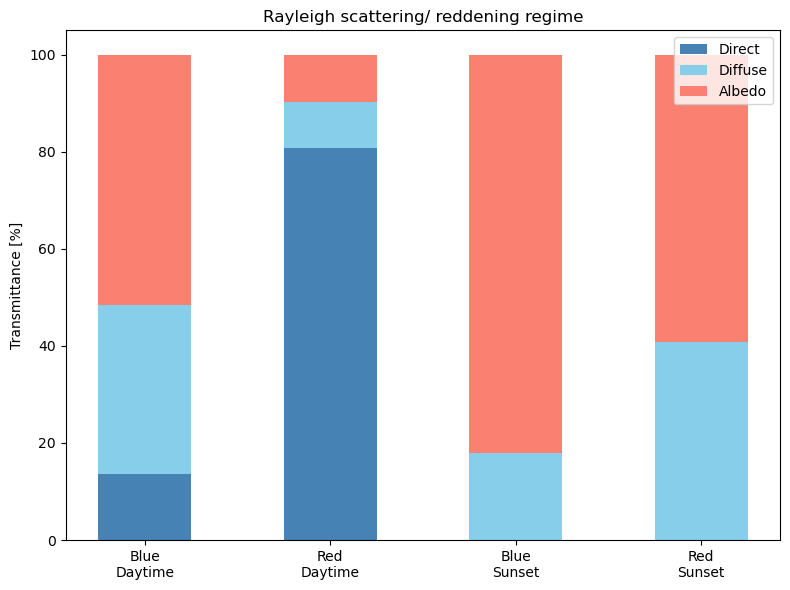

In [50]:
fig, ax = plt.subplots(figsize=(8, 6))

labels = ['Blue\nDaytime', 'Red\nDaytime', 'Blue\nSunset', 'Red\nSunset']

direct_pct  = np.array([dir_day_b,  dir_day_r,  dir_night_b,  dir_night_r])  / num_photons * 100
diffuse_pct = np.array([dif_day_b,  dif_day_r,  dif_night_b,  dif_night_r])  / num_photons * 100
albedo_pct  = np.array([alb_day_b,  alb_day_r,  alb_night_b,  alb_night_r])  / num_photons * 100

x = np.arange(len(labels))
width = 0.5

ax.bar(x, direct_pct,  width, label='Direct',  color='steelblue')
ax.bar(x, diffuse_pct, width, label='Diffuse',  color='skyblue',  bottom=direct_pct)
ax.bar(x, albedo_pct,  width, label='Albedo',   color='salmon',   bottom=direct_pct + diffuse_pct)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Transmittance [%]')
ax.set_title('Rayleigh scattering/ reddening regime')
ax.set_ylim(0, 105)
ax.legend()

plt.tight_layout()
plt.show()

### 1.3 Student Investigation
- Question: 
    - How does the number of scattering events change with the solar zenith angle?
- Experiment:
    - Keep the single scatter albedo fixed at 1 since I am only interested in scattering extinction events. Run the model at continuous values of theta and discrete values of tau star. Plot results to look for a functional dependence of the number of extinction events for both scattering out the top and bottom of the atmosphere.
- Expected results:
    - For direct transmittance, the number of extinction events should always be one.
    - For diffuse transmittance (scattering out bottom of atmosphere), the average number of scattering events should increase with solar zenith angle. I expect the number to increase sharply for angles > 80.
    - For albedo (scattering out top of atmosphere), I expect the number of scattering events to remain constant. Since scattering is isotropic and light enters at the top of the atmosphere, I suspect that there is no angluar dependence to the average number of scattering events.
    - For higher optical depths, I expect the number of diffuse extinction events to increase and albedo extinction events to decrease.
- Final results:
    - My hypothesis for direct transmittance was correct (or rather my model works properly!). For direct transmittance the number of extinction events is always one.
    - For diffuse transmittance, the number of extinction events was relatively constant for low angles, and started to increase for angles greater than 40. This did not match my intuition, as the number of extinction events did not jump sharply at high angles. Rather, extinction events increase almost linearly for angles greater than 40. 
    - Scattering out the top of the atmosphere behaved inversly to diffuse transmittance, decreasing as zenith angle increased. It also has a smoother curved fit for larger angles, with the uniform section shrinking for larger optical depths. This is contraray to my hypothesis.
    - For higher optical depths, both diffuse and albedo extionction events increased. 
    - An unexpected result was that extinction events out the top of the atmosphere increases ~ linearly with optical depth (for tau >= 1), but extinction events at the surface increased much more rapidly.
- Conclusions:
    - The relationship between extinction events and solar zenith angle could be modeled fairly well with a linear approximation. The number of extinction events is dominated by the optical depth more so than the zenith angle. The atmosphere can scatter light back out to space much more efficiently than it scatters light towards the surface.

In [51]:
# number of scattering events needed to reach the surface. is this a function of incidence angle?
df_u = pd.DataFrame({
    'u':np.linspace(0,89,100)
})

df_u_scattering_01 = df_u.apply(lambda x: monte_carlo_model(theta = x['u'], w = 1, tau_star = 0.1, num_photons=num_photons,ext_event_count=True),axis=1,result_type='expand').rename(columns={0:'direct',1:'diffuse',2:'albedo',3:'dir_ext',4:'diff_ext',5:'alb_ext'})
df_u_scattering_1 = df_u.apply(lambda x: monte_carlo_model(theta = x['u'], w = 1, tau_star = 1, num_photons=num_photons,ext_event_count=True),axis=1,result_type='expand').rename(columns={0:'direct',1:'diffuse',2:'albedo',3:'dir_ext',4:'diff_ext',5:'alb_ext'})
df_u_scattering_2 = df_u.apply(lambda x: monte_carlo_model(theta = x['u'], w = 1, tau_star = 2, num_photons=num_photons,ext_event_count=True),axis=1,result_type='expand').rename(columns={0:'direct',1:'diffuse',2:'albedo',3:'dir_ext',4:'diff_ext',5:'alb_ext'})
df_u_scattering_5 = df_u.apply(lambda x: monte_carlo_model(theta = x['u'], w = 1, tau_star = 5, num_photons=num_photons,ext_event_count=True),axis=1,result_type='expand').rename(columns={0:'direct',1:'diffuse',2:'albedo',3:'dir_ext',4:'diff_ext',5:'alb_ext'})
df_u_scattering_10 = df_u.apply(lambda x: monte_carlo_model(theta = x['u'], w = 1, tau_star = 10, num_photons=num_photons,ext_event_count=True),axis=1,result_type='expand').rename(columns={0:'direct',1:'diffuse',2:'albedo',3:'dir_ext',4:'diff_ext',5:'alb_ext'})


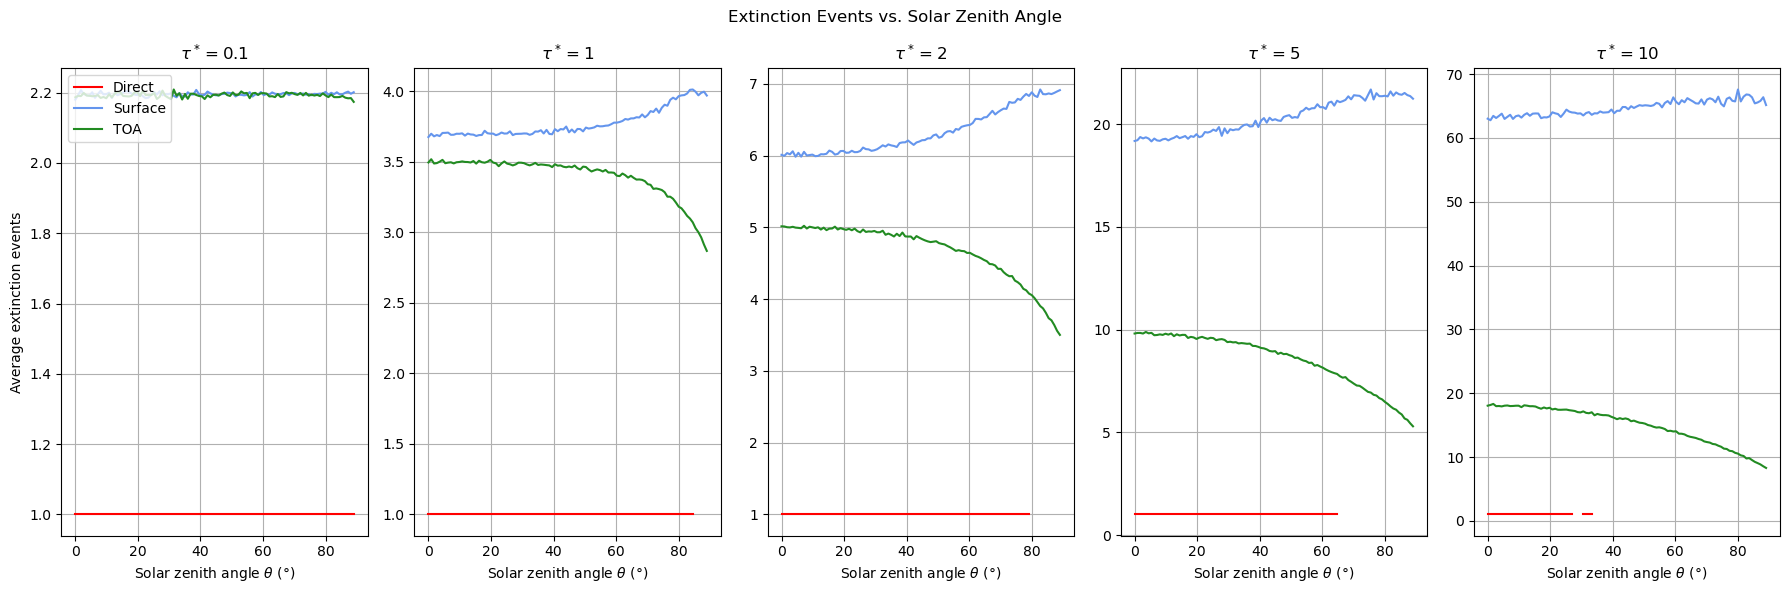

In [52]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1,5, figsize=(18, 6), sharey=False)

colors = {
    'dir_ext':  'red',
    'diff_ext': 'cornflowerblue',
    'alb_ext':  'forestgreen',
}
color_labels = {'dir_ext': 'Direct', 'diff_ext': 'Surface', 'alb_ext': 'TOA'}

datasets = [
    (df_u_scattering_01, r'$\tau^* = 0.1$'),
    (df_u_scattering_1,  r'$\tau^* = 1$'),
    (df_u_scattering_2,  r'$\tau^* = 2$'),
    (df_u_scattering_5,  r'$\tau^* = 5$'),
    (df_u_scattering_10,  r'$\tau^* = 10$'),
]

u = df_u['u'].values

for ax, (data, title) in zip(axes, datasets):
    for col, color in colors.items():
        ax.plot(u, data[col].values, color=color, linewidth=1.5, label=color_labels[col])
    ax.set_title(title)
    ax.set_xlabel(r'Solar zenith angle $\theta$ (°)')
    ax.grid(True)

axes[0].set_ylabel('Average extinction events')
axes[0].legend(loc='upper left')

plt.suptitle('Extinction Events vs. Solar Zenith Angle')
plt.tight_layout()
plt.show()

# AI Usage Statement
- Tool: Claude Code
- Prompt: "my model in scattering_model.ipynb is only scattering particles in the +x direction, but the scattering should be isotropic. Check the logic for `coord_rotation`, `photon_scattering_iso`, and `photon_path`."
- Outcome:
    - Found two syntax errors:
        - `np.sin(theta_sca * np.cos(phi_sca))` — `cos` was inside `sin`
        - `np.array([xp,yp,zp])` stacks as rows → `np.column_stack([xp,yp,zp])` so columns are basis vectors
    - Key bug: `np.arctan(y/x)` is restricted to $(-\pi/2,\, \pi/2)$, so $\cos(\phi_\text{new}) > 0$ always → this is the direct cause of the $+x$ bias
        - verified by reading documentation on numpy functions arctan and arctan2
    - Suggested moving `zeta` inside the `while` loop to vary path length and absorption vs. scattering potential
        - Same `zeta` reused every hop → identical step length for all scatter events
- Prompt: "create a stacked bar plot that shows the breakdown of direct, diffuse, and albedo for the red, blue, day and night cases. The x axis should have the four scenarios and the y axis should be percent"
    - modified plot labels
- Prompt: "Modify the markdown cells to use proper latex equation and symbol formatting and correct all spelling errors."
- Prompt: "Modify the final plot so that all the direct extinction events are red color, all the diffuse extinction events are blue color, and all the albedo extinction events are green. i want each optical depth on a seperate subplot. So the figuer should have one row and three columns"
    - modified code to add additional plots
- Prompt: "Vectorize model across n photons"
    - verified outputs were same as model prior to changes
- Prompt: "The analytical expression I want to compare my model to in part 1.3 question 2 is Tdiffuse = (tau/mu)*single scatter albedo * 0.5. Give me code that creates a four panel figure. Each panel is for one incidence angle (or mu value). The angles should be 0, 30, 60, 90. The plots should have optical depth (tau) on the x axis and diffuse transmittance on the y axis. Each plot should show the solutions for three single scatter albedos (0, 0.5, 1), plotting the model output and analytical solution."
    - modified constant parameters slightly